In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils 


import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore",category=DeprecationWarning)
    import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

import seaborn as sns

warnings.filterwarnings("ignore", 
    ".*Consider increasing the value of the `num_workers` argument*")
warnings.filterwarnings("ignore", 
    ".*Set a lower value for log_every_n_steps "
    "if you want to see logs for the training epoch")

# local imports
from rosetta_db import get_sqlite_dbcon
import utils 
from train_vaes_phils_nb import get_aaindex_embedding


pl.utilities.seed.seed_everything(1111)

Global seed set to 1111


1111

In [2]:
# setup torchtext vocab to map AAs to indices, usage is aa2ind(list(AAsequence))
AAs = 'ACDEFGHIKLMNPQRSTVWY'
aa2ind_dict = {a:i for i, a in enumerate(AAs)}

In [3]:
class RosettaSQLdf(torch.utils.data.Dataset):
   
    def __init__(self, df, parent_seq, dtype=torch.float32):
        self.df = df
        self.dtype = dtype
        self.parent_seq = parent_seq
        self.parent_enc = list(map(aa2ind_dict.get, self.parent_seq))
        
    def __getitem__(self, idx):
        energies = torch.tensor(self.df.iloc[idx][1:-1], dtype=self.dtype)
        seq_list = utils.expand_mut_str_list_to_list(
                self.df.iloc[idx, -1], self.parent_enc, encoder=aa2ind_dict.get,
                split_mut_char=".", offset=1)
        seq = torch.tensor(seq_list, dtype=torch.int)
        return seq, energies

    def __len__(self):
        return len(self.df)

In [4]:
class RosettaEnergiesDataModule(pl.LightningDataModule):
    
    def __init__(self, parent = "2D", batch_size=32, dtype=torch.float32, num_workers=1):
        super().__init__()
        self.parent = parent
        self.batch_size = batch_size
        self.dtype = dtype
        self.num_workers = num_workers
        
        # read sequence and encode
        self.parent_seq = utils.get_parent_seq(parent=self.parent)
        self.slen = len(self.parent_seq)
        #self.parent_enc = list(map(aa2ind_dict.get, self.parent))

        # read in data from database
        db_con = get_sqlite_dbcon(parent=self.parent)
        self.df = pd.read_sql("select * from relaxed_scores limit 100000", db_con)
        
        del self.df["description"]
        del self.df["dslf_fa13"] # disulfide bond energy
        
        # number of parameters to predict
        self.nparam = len(self.df.columns) - 2 # dropping first (total energy) and last column (variant)

        
        N = len(self.df)
        train_val_test_split = [0.8, 0.1, 0.1]
        n_train_val_test = np.round(np.array(train_val_test_split)*N).astype(int)
        n_train_val_test[-1] = (N  - n_train_val_test[:-1].sum())
        self.train_idx, self.val_idx, self.test_idx = \
                data_utils.random_split(range(N),n_train_val_test)

    def prepare_data(self):
        # prepare_data is called from a single GPU. Do not use it to assign state (self.x = y)
        # use this method to do things that might write to disk or that need to be done only from a single process
        # in distributed settings.
        pass

    
    def setup(self, stage=None):
              
        # Assign train/val datasets for use in dataloaders
        if stage == 'fit' or stage is None:
            self.train_data = RosettaSQLdf(self.df.iloc[list(self.train_idx),], self.parent_seq)
            self.val_data = RosettaSQLdf(self.df.iloc[list(self.val_idx),], self.parent_seq)
            
        # Assign test dataset for use in dataloader(s)
        if stage == 'test' or stage is None:
            self.test_data = RosettaSQLdf(self.df.iloc[list(self.test_idx),], self.parent_seq)

    def train_dataloader(self):
        return data_utils.DataLoader(self.train_data, batch_size=self.batch_size, 
                                         shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return data_utils.DataLoader(self.val_data, batch_size=self.batch_size,
                                        num_workers=self.num_workers)

    def test_dataloader(self):
        return data_utils.DataLoader(self.test_data, batch_size=self.batch_size, 
                                        num_workers=self.num_workers)
    
    def predict_dataloader(self):
        return self.test_dataloader()

rd = RosettaEnergiesDataModule(parent="2D")

# rd.setup()
# for x in rd.test_dataloader():
#     break
# print(x[0].shape)
# print(x[1].shape)

In [5]:
class RosettaEnergyPrediction(pl.LightningModule):
    
    def __init__(self, slen, nparam, embed_ncomp=0, embed_freeze=True, learning_rate=0.01, ):
        
        super().__init__()

        ## GENERAL INPUT PARAMETERS
        self.slen = slen # sequence length
        self.nparam = nparam # number of energy terms to predict
        self.q = 20 # amino acid alphabet_size (without gaps)
        
        self.learning_rate = learning_rate
        
        if embed_ncomp: # if non-zero get a pretrained PCA embedding of Amino acids based on physiochemical properties
            aaindex = get_aaindex_embedding(ncomp=embed_ncomp)
            aaindex = aaindex[:-1, :] # drop the gap character
            assert(aaindex.shape[0] == self.q)
        else: # if embed_ncomp is zero then do one-hot encoding
            aaindex = torch.eye(self.q)
            
            
        self.embed = nn.Embedding.from_pretrained(aaindex, freeze=embed_freeze)
        self.edim = self.embed.embedding_dim # dimensions of AA embedding
       
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(self.edim*self.slen, self.nparam)
        
        # save hyperparameters for logging 
        self.save_hyperparameters()
        
    def forward(self, x):
        x = self.embed(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x
    
    def shared_step(self, batch):
        x, y = batch
        # pass through network
        out = self(x)
        
        # calculate loss
        return nn.MSELoss()(out, y)
        
    def training_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        self.log("train_loss", loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        self.log("val_loss", loss)
        return loss
    
    def test_step(self, batch, batch_idx):
        return self.shared_step(batch)
    
    def predict_step(self, batch, batch_idx):
        x, y = batch
        return self(x), y
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [6]:
dm = RosettaEnergiesDataModule(parent = "2D")

In [7]:
# one-hot encoded and frozen
#model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam)

# PCA embedding and allowing embedding to be trained
#model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam, embed_freeze=False, embed_ncomp=8)

# PCA embedding and not allowing embedding to be trained
model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam, embed_freeze=True, embed_ncomp=8)


In [8]:
# train 
logger = CSVLogger('logs', name='Linear')
trainer = pl.Trainer(logger=logger
                     ,max_epochs=50
                     ,gpus=0
                     #,enable_progress_bar=False
                    )
trainer.fit(model,dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs

  | Name    | Type      | Params
--------------------------------------
0 | embed   | Embedding | 160   
1 | flatten | Flatten   | 0     
2 | linear  | Linear    | 39.3 K
--------------------------------------
39.3 K    Trainable params
160       Non-trainable params
39.5 K    Total params
0.158     Total estimated model params size (MB)


Global seed set to 1111


Epoch 0:  89% 2500/2813 [00:33<00:04, 75.29it/s, loss=14.2, v_num=28]   
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/313 [00:00<?, ?it/s]
Epoch 0:  89% 2503/2813 [00:33<00:04, 75.03it/s, loss=14.2, v_num=28]
Epoch 0:  89% 2512/2813 [00:33<00:04, 74.98it/s, loss=14.2, v_num=28]
Epoch 0:  90% 2521/2813 [00:33<00:03, 74.94it/s, loss=14.2, v_num=28]
Epoch 0:  90% 2530/2813 [00:33<00:03, 74.94it/s, loss=14.2, v_num=28]
Epoch 0:  90% 2539/2813 [00:33<00:03, 74.95it/s, loss=14.2, v_num=28]
Validating:  12% 39/313 [00:00<00:04, 68.06it/s]
Epoch 0:  91% 2548/2813 [00:33<00:03, 74.95it/s, loss=14.2, v_num=28]
Epoch 0:  91% 2557/2813 [00:34<00:03, 74.95it/s, loss=14.2, v_num=28]
Epoch 0:  91% 2566/2813 [00:34<00:03, 74.96it/s, loss=14.2, v_num=28]
Epoch 0:  92% 2575/2813 [00:34<00:03, 74.97it/s, loss=14.2, v_num=28]
Epoch 0:  92% 2584/2813 [00:34<00:03, 74.96it/s, loss=14.2, v_num=28]
Epoch 0:  92% 2593/2813 [00:34<00:02, 74.95it/s, loss=14.2, v_num=28]
Epoch 0:  92% 2602/2813 [00:34<00:02,

Epoch 2: 100% 2799/2813 [00:37<00:00, 73.72it/s, loss=10.2, v_num=28]
Epoch 2: 100% 2808/2813 [00:38<00:00, 73.73it/s, loss=10.2, v_num=28]
Epoch 2: 100% 2813/2813 [00:38<00:00, 73.73it/s, loss=10.2, v_num=28]
Epoch 3:  89% 2500/2813 [00:34<00:04, 72.92it/s, loss=32.5, v_num=28]
Validating: 0it [00:00, ?it/s]
Epoch 3:  89% 2502/2813 [00:34<00:04, 72.77it/s, loss=32.5, v_num=28]
Epoch 3:  89% 2511/2813 [00:34<00:04, 72.80it/s, loss=32.5, v_num=28]
Validating:   4% 11/313 [00:00<00:05, 57.16it/s]
Epoch 3:  90% 2520/2813 [00:34<00:04, 72.81it/s, loss=32.5, v_num=28]
Epoch 3:  90% 2529/2813 [00:34<00:03, 72.84it/s, loss=32.5, v_num=28]
Epoch 3:  90% 2538/2813 [00:34<00:03, 72.87it/s, loss=32.5, v_num=28]
Epoch 3:  91% 2547/2813 [00:34<00:03, 72.90it/s, loss=32.5, v_num=28]
Epoch 3:  91% 2556/2813 [00:35<00:03, 72.92it/s, loss=32.5, v_num=28]
Epoch 3:  91% 2565/2813 [00:35<00:03, 72.96it/s, loss=32.5, v_num=28]
Epoch 3:  92% 2574/2813 [00:35<00:03, 72.89it/s, loss=32.5, v_num=28]
Epoch 3:  

Epoch 5:  99% 2781/2813 [00:36<00:00, 75.60it/s, loss=12, v_num=28]
Epoch 5:  99% 2790/2813 [00:36<00:00, 75.62it/s, loss=12, v_num=28]
Epoch 5: 100% 2799/2813 [00:37<00:00, 75.63it/s, loss=12, v_num=28]
Epoch 5: 100% 2813/2813 [00:37<00:00, 75.64it/s, loss=12, v_num=28]
Epoch 6:  89% 2500/2813 [00:33<00:04, 74.35it/s, loss=25.2, v_num=28]
Validating: 0it [00:00, ?it/s]
Epoch 6:  89% 2502/2813 [00:33<00:04, 74.20it/s, loss=25.2, v_num=28]
Validating:   1% 2/313 [00:00<00:16, 19.32it/s]
Epoch 6:  89% 2511/2813 [00:33<00:04, 74.18it/s, loss=25.2, v_num=28]
Epoch 6:  90% 2520/2813 [00:33<00:03, 74.20it/s, loss=25.2, v_num=28]
Epoch 6:  90% 2529/2813 [00:34<00:03, 74.22it/s, loss=25.2, v_num=28]
Epoch 6:  90% 2538/2813 [00:34<00:03, 74.25it/s, loss=25.2, v_num=28]
Epoch 6:  91% 2547/2813 [00:34<00:03, 74.28it/s, loss=25.2, v_num=28]
Epoch 6:  91% 2556/2813 [00:34<00:03, 74.30it/s, loss=25.2, v_num=28]
Epoch 6:  91% 2565/2813 [00:34<00:03, 74.33it/s, loss=25.2, v_num=28]
Epoch 6:  92% 2574/

...

Epoch 37:  99% 2790/2813 [00:37<00:00, 74.99it/s, loss=7.58, v_num=28]
Epoch 37: 100% 2799/2813 [00:37<00:00, 74.98it/s, loss=7.58, v_num=28]
Epoch 37: 100% 2808/2813 [00:37<00:00, 75.00it/s, loss=7.58, v_num=28]
Epoch 37: 100% 2813/2813 [00:37<00:00, 74.97it/s, loss=7.58, v_num=28]
Epoch 38:  89% 2500/2813 [00:33<00:04, 74.08it/s, loss=6.98, v_num=28]
Validating: 0it [00:00, ?it/s]
Epoch 38:  89% 2502/2813 [00:33<00:04, 73.89it/s, loss=6.98, v_num=28]
Validating:   1% 2/313 [00:00<00:16, 18.31it/s]
Epoch 38:  89% 2511/2813 [00:34<00:04, 73.81it/s, loss=6.98, v_num=28]
Epoch 38:  90% 2520/2813 [00:34<00:03, 73.82it/s, loss=6.98, v_num=28]
Epoch 38:  90% 2529/2813 [00:34<00:03, 73.82it/s, loss=6.98, v_num=28]
Epoch 38:  90% 2538/2813 [00:34<00:03, 73.83it/s, loss=6.98, v_num=28]
Epoch 38:  91% 2547/2813 [00:34<00:03, 73.85it/s, loss=6.98, v_num=28]
Epoch 38:  91% 2556/2813 [00:34<00:03, 73.86it/s, loss=6.98, v_num=28]
Validating:  18% 56/313 [00:00<00:03, 74.64it/s]
Epoch 38:  91% 2565/

Epoch 40:  98% 2745/2813 [00:37<00:00, 73.22it/s, loss=5.22, v_num=28]
Epoch 40:  98% 2754/2813 [00:37<00:00, 73.24it/s, loss=5.22, v_num=28]
Epoch 40:  98% 2763/2813 [00:37<00:00, 73.26it/s, loss=5.22, v_num=28]
Epoch 40:  99% 2772/2813 [00:37<00:00, 73.28it/s, loss=5.22, v_num=28]
Epoch 40:  99% 2781/2813 [00:37<00:00, 73.30it/s, loss=5.22, v_num=28]
Epoch 40:  99% 2790/2813 [00:38<00:00, 73.32it/s, loss=5.22, v_num=28]
Epoch 40: 100% 2799/2813 [00:38<00:00, 73.34it/s, loss=5.22, v_num=28]
Epoch 40: 100% 2808/2813 [00:38<00:00, 73.37it/s, loss=5.22, v_num=28]
Epoch 40: 100% 2813/2813 [00:38<00:00, 73.33it/s, loss=5.22, v_num=28]
Epoch 41:  89% 2500/2813 [00:33<00:04, 73.82it/s, loss=8.54, v_num=28]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/313 [00:00<?, ?it/s]
Epoch 41:  89% 2502/2813 [00:34<00:04, 73.58it/s, loss=8.54, v_num=28]
Epoch 41:  89% 2511/2813 [00:34<00:04, 73.51it/s, loss=8.54, v_num=28]
Epoch 41:  90% 2520/2813 [00:34<00:03, 73.50it/s, loss=8.54, v_num=28]
Epoch 

Epoch 43:  97% 2718/2813 [00:37<00:01, 71.75it/s, loss=4.93, v_num=28]
Epoch 43:  97% 2727/2813 [00:37<00:01, 71.77it/s, loss=4.93, v_num=28]
Epoch 43:  97% 2736/2813 [00:38<00:01, 71.79it/s, loss=4.93, v_num=28]
Epoch 43:  98% 2745/2813 [00:38<00:00, 71.81it/s, loss=4.93, v_num=28]
Epoch 43:  98% 2754/2813 [00:38<00:00, 71.84it/s, loss=4.93, v_num=28]
Epoch 43:  98% 2763/2813 [00:38<00:00, 71.83it/s, loss=4.93, v_num=28]
Epoch 43:  99% 2772/2813 [00:38<00:00, 71.72it/s, loss=4.93, v_num=28]
Epoch 43:  99% 2781/2813 [00:38<00:00, 71.74it/s, loss=4.93, v_num=28]
Validating:  90% 281/313 [00:03<00:00, 68.83it/s]
Epoch 43:  99% 2790/2813 [00:38<00:00, 71.75it/s, loss=4.93, v_num=28]
Epoch 43: 100% 2799/2813 [00:38<00:00, 71.77it/s, loss=4.93, v_num=28]
Epoch 43: 100% 2813/2813 [00:39<00:00, 71.75it/s, loss=4.93, v_num=28]
Epoch 44:  89% 2500/2813 [00:34<00:04, 72.07it/s, loss=4.88, v_num=28]
Validating: 0it [00:00, ?it/s]
Epoch 44:  89% 2502/2813 [00:34<00:04, 71.90it/s, loss=4.88, v_num=

Epoch 46:  95% 2664/2813 [00:36<00:02, 72.92it/s, loss=5.58, v_num=28]
Epoch 46:  95% 2673/2813 [00:36<00:01, 72.94it/s, loss=5.58, v_num=28]
Epoch 46:  95% 2682/2813 [00:36<00:01, 72.97it/s, loss=5.58, v_num=28]
Epoch 46:  96% 2691/2813 [00:36<00:01, 72.99it/s, loss=5.58, v_num=28]
Epoch 46:  96% 2700/2813 [00:36<00:01, 73.01it/s, loss=5.58, v_num=28]
Epoch 46:  96% 2709/2813 [00:37<00:01, 73.04it/s, loss=5.58, v_num=28]
Epoch 46:  97% 2718/2813 [00:37<00:01, 73.06it/s, loss=5.58, v_num=28]
Epoch 46:  97% 2727/2813 [00:37<00:01, 73.09it/s, loss=5.58, v_num=28]
Epoch 46:  97% 2736/2813 [00:37<00:01, 73.10it/s, loss=5.58, v_num=28]
Epoch 46:  98% 2745/2813 [00:37<00:00, 73.12it/s, loss=5.58, v_num=28]
Epoch 46:  98% 2754/2813 [00:37<00:00, 73.15it/s, loss=5.58, v_num=28]
Epoch 46:  98% 2763/2813 [00:37<00:00, 73.16it/s, loss=5.58, v_num=28]
Epoch 46:  99% 2772/2813 [00:37<00:00, 73.18it/s, loss=5.58, v_num=28]
Epoch 46:  99% 2781/2813 [00:37<00:00, 73.20it/s, loss=5.58, v_num=28]
Epoch 

Epoch 49:  93% 2628/2813 [00:35<00:02, 73.86it/s, loss=8.4, v_num=28]
Epoch 49:  94% 2637/2813 [00:35<00:02, 73.87it/s, loss=8.4, v_num=28]
Epoch 49:  94% 2646/2813 [00:35<00:02, 73.88it/s, loss=8.4, v_num=28]
Epoch 49:  94% 2655/2813 [00:35<00:02, 73.90it/s, loss=8.4, v_num=28]
Epoch 49:  95% 2664/2813 [00:36<00:02, 73.91it/s, loss=8.4, v_num=28]
Epoch 49:  95% 2673/2813 [00:36<00:01, 73.93it/s, loss=8.4, v_num=28]
Epoch 49:  95% 2682/2813 [00:36<00:01, 73.93it/s, loss=8.4, v_num=28]
Validating:  58% 182/313 [00:02<00:01, 77.20it/s]
Epoch 49:  96% 2691/2813 [00:36<00:01, 73.95it/s, loss=8.4, v_num=28]
Epoch 49:  96% 2700/2813 [00:36<00:01, 73.97it/s, loss=8.4, v_num=28]
Epoch 49:  96% 2709/2813 [00:36<00:01, 73.99it/s, loss=8.4, v_num=28]
Epoch 49:  97% 2718/2813 [00:36<00:01, 74.00it/s, loss=8.4, v_num=28]
Epoch 49:  97% 2727/2813 [00:36<00:01, 74.03it/s, loss=8.4, v_num=28]
Epoch 49:  97% 2736/2813 [00:36<00:01, 74.04it/s, loss=8.4, v_num=28]
Epoch 49:  98% 2745/2813 [00:37<00:00, 7

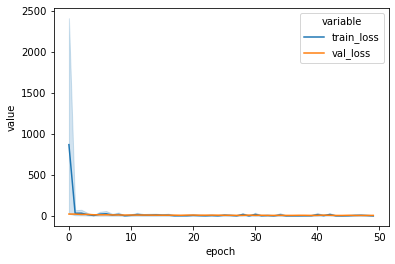

In [9]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
metrics_melt = pd.melt(metrics, id_vars=["epoch", "step"]).dropna()
g = sns.lineplot(x="epoch", y="value", hue="variable", data=metrics_melt)
g.get_figure().savefig(f"{logger.log_dir}/losses.png", dpi=300)

In [10]:
dm.setup("test") # as we predict on the test set
ret = trainer.predict(model, dm)

predictions = torch.cat([batch[0].sum(dim=1) for batch in ret])
values = torch.cat([batch[1].sum(dim=1) for batch in ret])
print(f"Number of predictions : {len(predictions)}")

Predicting: 2500it [00:04, ?it/s]
Number of predictions : 10000


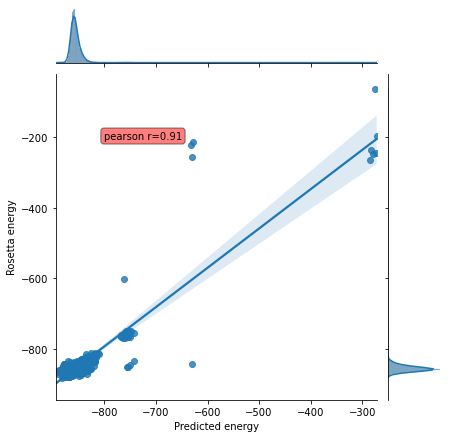

In [11]:
import scipy as sp


g = sns.jointplot(y=values.numpy(), x=predictions.numpy(), kind='reg')
pearson_r = sp.stats.pearsonr(predictions, values)

ax = g.ax_joint
ax.text(0.15, 0.8, f"pearson r={pearson_r[0]:.2f}", 
        horizontalalignment='left',
        bbox=dict(boxstyle="round", facecolor='red', alpha=0.5),
        transform=ax.transAxes)


ax.set_ylabel("Rosetta energy")
ax.set_xlabel("Predicted energy")


pass

In [12]:
pl.__version__

'1.5.3'